# VaR / Expected-Shortfall backtest — does forecastable volatility pay off?

The variance chapter (`02_har` / `03` / `04`) showed that weekly silver realised volatility is
forecastable, and that Reddit / paid-news attention adds a small but **QLIKE-significant**
increment over bare HAR. This notebook asks the **risk-management relevance** question that a
statistical loss alone cannot answer: does that forecast quality translate into better
**tail-risk management**?

### From a volatility forecast to VaR

The return model behind the calculation is
$$r_t = \mu + \hat\sigma_t z_t.$$
Taking its lower $\alpha$-quantile gives the one-week return cutoff
$$\boxed{\mathrm{VaR}_t(\alpha) = \mu + \hat\sigma_t q_\alpha}.$$

- $\mu$ is the mean weekly return estimated on the training sample (about $0.117\%$ here).
- $\hat\sigma_t$ is the model's forecast of next week's **volatility**.
- $q_\alpha$ is the lower-tail quantile of a standardised innovation: under Normality,
  $q_{5\%}=-1.645$ and $q_{1\%}=-2.326$.
- Because $q_\alpha<0$, higher forecast volatility makes the VaR cutoff more negative.

**Terminology that matters:** although the project uses the conventional label `RV`, its target is
realised **volatility**, $\mathrm{RV}_t=\sqrt{\sum_{i\in t}r_i^2}$, not an untransformed
variance. It is therefore already on the $\sigma$ scale and enters the VaR formula directly. If a
model instead supplied a variance forecast $\hat v_t$, the formula would use
$\hat\sigma_t=\sqrt{\hat v_t}$.

For example, with $\mu=0.117\%$ and $\hat\sigma_t=3\%$, Normal 5% VaR is
$$0.117\%+3\%(-1.645)\approx-4.82\%.$$
This means a 5% probability of a return below $-4.82\%$ under the model; it is not the worst
possible loss. The notebook uses the negative-return convention (finance reports sometimes quote
the same quantity as a positive 4.82% loss). A **breach** occurs when the realised return satisfies
$r_t < \mathrm{VaR}_t(\alpha)$; it does **not** mean that realised variance exceeded forecast
variance.

We backtest **coverage** (Kupiec POF; Christoffersen conditional
coverage), the **pinball/quantile loss** (a proper VaR score), and **Expected Shortfall**,
comparing the naïve $\mathrm{RV}_{t-1}$ floor, GARCH(1,1), bare HAR, and the HAR sentiment rungs
(Reddit attention, Reddit sentiment, paid-news attention, combined paid) on the common 174-week
test window. Every row uses the same $\mu$, dates, returns and innovation distribution; only
$\hat\sigma_t$ changes. The naïve row uses last week's realised volatility, GARCH supplies the
square root of its forecast variance, and the HAR rows forecast realised volatility from HAR lags
with or without the stated attention/sentiment block.

In [1]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

P = '../../data/processed'

# realised weekly return + constant train-period drift
vw  = pd.read_csv(f'{P}/volatility_weekly.csv', parse_dates=['Date'])
mu  = vw.loc[vw['split'] == 'train', 'silver_ret'].mean()
ret = vw.set_index('Date')['silver_ret']

# Forecast volatility (already on the sigma scale) per model on the test window.
# Despite the conventional RV label, these are NOT untransformed variance forecasts.
har_s = pd.read_csv(f'{P}/pred_har_sentiment_volatility.csv', parse_dates=['Date']).set_index('Date')
har_h = pd.read_csv(f'{P}/pred_har_volatility.csv',           parse_dates=['Date']).set_index('Date')
gar   = pd.read_csv(f'{P}/pred_garch_volatility.csv',         parse_dates=['Date']).set_index('Date')

idx = har_s.index
r   = ret.reindex(idx).values
SIG = {
    'Naive (RV_{t-1})':  har_h['naive'].reindex(idx).values,
    'GARCH(1,1)':        gar['garch'].reindex(idx).values,
    'HAR':                 har_s['HAR'].values,
    'HAR+RedditAttention': har_s['HAR+RedditAttention'].values,
    'HAR+RedditSent':      har_s['HAR+RedditSent'].values,
    'HAR+PaidAttention':   har_s['HAR+PaidAttention'].values,
    'HAR+Paid':            har_s['HAR+Paid'].values,
}
print(f'test weeks = {len(r)},  drift mu = {mu:.5f}')

test weeks = 174,  drift mu = 0.00117


## Backtest machinery

The functions below calculate four different diagnostics; none should be read in isolation.

1. **Kupiec POF** ($\chi^2_1$) tests whether the total breach rate equals $\alpha$.
2. **Christoffersen conditional coverage** ($\chi^2_2$) jointly tests the breach rate and whether
   breaches are independent rather than clustered.
3. **Pinball loss** scores the VaR cutoff every week:
   $$L_\alpha(r_t,V_t)=\begin{cases}
   \alpha(r_t-V_t),&r_t\geq V_t,\\
   (1-\alpha)(V_t-r_t),&r_t<V_t.
   \end{cases}$$
   A breach is therefore penalised much more heavily than a non-breach miss; lower is better.
4. **Expected Shortfall (ES)** asks how severe losses are once VaR is breached:
   $\mathrm{ES}_t(\alpha)=\mathbb{E}[r_t\mid r_t<V_t]$.

The `dm_loss` helper runs a Newey–West(1) Diebold–Mariano test on two per-week pinball-loss
series. With $d_t=L_{1,t}-L_{2,t}$, a positive DM statistic favours the **second** model and a
negative statistic favours the **first**; a small $p$-value says the loss difference is unlikely
to be sampling noise.

In [2]:
def z_alpha(alpha, dist='normal', nu=5):
    if dist == 'normal':
        return stats.norm.ppf(alpha)
    return stats.t.ppf(alpha, nu) * np.sqrt((nu - 2) / nu)   # unit-variance t

def kupiec(hits, alpha):
    n, x = len(hits), int(hits.sum()); pihat = x / n
    if x == 0:
        lr = -2 * (n * np.log(1 - alpha))
    else:
        lr = -2 * ((n - x) * np.log(1 - alpha) + x * np.log(alpha)
                   - (n - x) * np.log(1 - pihat) - x * np.log(pihat))
    return lr, 1 - stats.chi2.cdf(lr, 1)

def christoffersen(hits, alpha):
    h = hits.astype(int); n00 = n01 = n10 = n11 = 0
    for a, b in zip(h[:-1], h[1:]):
        n00 += (a == 0 and b == 0); n01 += (a == 0 and b == 1)
        n10 += (a == 1 and b == 0); n11 += (a == 1 and b == 1)
    p01 = n01 / (n00 + n01) if (n00 + n01) else 0
    p11 = n11 / (n10 + n11) if (n10 + n11) else 0
    pi  = (n01 + n11) / (n00 + n01 + n10 + n11)
    ll  = lambda p, k1, k0: 0.0 if (p <= 0 or p >= 1) else k1 * np.log(p) + k0 * np.log(1 - p)
    lr_ind = -2 * (ll(pi, n01 + n11, n00 + n10) - (ll(p01, n01, n00) + ll(p11, n11, n10)))
    lr_cc  = kupiec(hits, alpha)[0] + lr_ind
    return 1 - stats.chi2.cdf(lr_cc, 2)

def pinball_series(r, var, alpha):
    # `var` means the VaR return cutoff here, not statistical variance.
    u = r - var
    return np.where(u >= 0, alpha * u, (alpha - 1) * u)

def es_pair(r, var, sig_v, alpha, mu, dist, nu=5):
    hits = r < var
    if hits.sum() == 0:
        return np.nan, np.nan
    if dist == 'normal':
        mult = -stats.norm.pdf(stats.norm.ppf(alpha)) / alpha
    else:
        za = stats.t.ppf(alpha, nu)
        mult = -(stats.t.pdf(za, nu) / alpha) * (nu + za**2) / (nu - 1) * np.sqrt((nu - 2) / nu)
    return r[hits].mean(), mu + sig_v[hits].mean() * mult

def dm_loss(l1, l2):
    d = l1 - l2; n = len(d); db = d.mean()
    g0 = np.mean((d - db) ** 2); g1 = np.mean((d[1:] - db) * (d[:-1] - db))
    stat = db / np.sqrt((g0 + 2 * g1) / n)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))

## Coverage, pinball loss and Expected Shortfall

For each forecast and tail level, read the columns as follows:

| Column | Meaning | What do we want? |
|---|---|---|
| `n_viol` | Number of VaR breaches | **Close to $n\alpha$**: about 8.7 at 5%, 1.7 at 1% |
| `viol_rate` | Breaches divided by 174 | **Close to $\alpha$**: 0.05 for 5% VaR, 0.01 for 1% VaR |
| `kupiec_p` | Test of correct total breach frequency | **Want $p>0.05$** so coverage is not rejected; this does not prove perfection |
| `cc_p` | Test of correct frequency plus non-clustered breaches | **Want $p>0.05$** so conditional coverage is not rejected |
| `pinball_e4` | Mean quantile loss, multiplied by $10^4$ for readability | **Want lower**; use the DM test to decide whether a difference is significant |
| `realized_es` | Average realised return among that model's breach weeks | No universal high/low target; compare it with that row's `pred_es` |
| `pred_es` | Model-implied average return beyond its VaR | **Want close to `realized_es`**; equivalently, want a small absolute ES gap |

**Quick rule:** for Kupiec and conditional coverage, we want $p>0.05$ because the null is
"calibration is adequate." For the DM comparison, we want $p<0.05$ because the null is "the two
models have equal pinball accuracy." The DM sign then identifies the winner: positive favours the
second named model; negative favours the first.

Realised ES is not directly rankable across rows because each model can select a different breach
set. A model with too many breaches can include moderate losses and consequently display a
less-negative realised ES. At the 1% tail, all ES and coverage conclusions are fragile: only about
1.7 breaches are expected in 174 weeks, so one observation can change the verdict.

In [3]:
rows = []
for dist in ['normal', 't5']:
    d = 'normal' if dist == 'normal' else 't'
    for alpha in [0.05, 0.01]:
        za = z_alpha(alpha, d)
        for name, s in SIG.items():
            var  = mu + s * za  # VaR return cutoff; `s` is forecast volatility, not variance
            hits = r < var
            rows.append(dict(
                dist=dist, alpha=alpha, model=name,
                n_viol=int(hits.sum()), viol_rate=round(hits.mean(), 4),
                kupiec_p=round(kupiec(hits, alpha)[1], 3),
                cc_p=round(christoffersen(hits, alpha), 3),
                pinball_e4=round(pinball_series(r, var, alpha).mean() * 1e4, 3),
                realized_es=round(es_pair(r, var, s, alpha, mu, d)[0], 4),
                pred_es=round(es_pair(r, var, s, alpha, mu, d)[1], 4)))
res = pd.DataFrame(rows)
res.to_csv(f'{P}/metrics_var_backtest_volatility.csv', index=False)
pd.set_option('display.width', 200, 'display.max_columns', 20)
print('=== Normal innovations ===')
print(res[res.dist == 'normal'].drop(columns='dist').to_string(index=False))
print('\n=== Student-t(5) innovations ===')
print(res[res.dist == 't5'].drop(columns='dist').to_string(index=False))

=== Normal innovations ===
 alpha               model  n_viol  viol_rate  kupiec_p  cc_p  pinball_e4  realized_es  pred_es
  0.05    Naive (RV_{t-1})      14     0.0805     0.089 0.069      66.330      -0.0889  -0.0709
  0.05          GARCH(1,1)       6     0.0345     0.321 0.493      58.468      -0.1221  -0.0879
  0.05                 HAR      11     0.0632     0.441 0.352      59.603      -0.1010  -0.0842
  0.05 HAR+RedditAttention      10     0.0575     0.658 0.491      59.577      -0.1059  -0.0863
  0.05      HAR+RedditSent      10     0.0575     0.658 0.491      59.455      -0.1059  -0.0867
  0.05   HAR+PaidAttention      10     0.0575     0.658 0.491      59.703      -0.1059  -0.0867
  0.05            HAR+Paid      10     0.0575     0.658 0.491      59.617      -0.1059  -0.0869
  0.01    Naive (RV_{t-1})       7     0.0402     0.003 0.008      24.132      -0.1113  -0.0907
  0.01          GARCH(1,1)       3     0.0172     0.384 0.649      20.772      -0.1774  -0.1399
  0.01       

**Reading the output.** At Normal 5% VaR, about nine breaches are expected. The naïve forecast
produces 14 (risk underestimated), GARCH 6 (somewhat conservative), HAR 11, and the sentiment HAR
rungs 10; all nevertheless pass Kupiec and conditional coverage at the 5% test level. Pinball loss
shows the clearer distinction: GARCH and the HAR family improve materially on the naïve cutoff.

At Normal 1% VaR, only about 1.7 breaches are expected. The naïve model's seven breaches are
strongly rejected (Kupiec $p=0.003$); bare HAR's five are marginally rejected ($p=0.043$), while
GARCH's three and HAR + Reddit attention's four are not rejected. Do not call Reddit's result
proof of correct calibration: it differs from bare HAR by only one breach. HAR + Paid has the
lowest numerical Normal-1% pinball loss among the HAR rows, whereas Reddit has the strongest DM
evidence and is the only displayed sentiment rung whose Normal-1% Kupiec test passes.

The Student-$t_5$ assumption makes the 1% cutoff more negative and allows bare HAR to pass. This
shows that deep-tail calibration depends at least as much on the innovation distribution as on
the sentiment extension. GARCH is best described as **well calibrated and competitive**, not
uniformly conservative.

In [4]:
# DM on Normal-VaR pinball loss only: naive vs HAR, then HAR vs two sentiment rungs.
print('DM on pinball loss  (negative => first model better):')
for alpha in [0.05, 0.01]:
    za = z_alpha(alpha, 'normal')
    pl = {k: pinball_series(r, mu + s * za, alpha) for k, s in SIG.items()}
    for a, b in [('Naive (RV_{t-1})', 'HAR'), ('HAR', 'HAR+RedditAttention'), ('HAR', 'HAR+Paid')]:
        st, p = dm_loss(pl[a], pl[b])
        print(f'  alpha={alpha:.0%}  {a:18s} vs {b:20s}: DM={st:+.3f}  p={p:.3f}')

DM on pinball loss  (negative => first model better):
  alpha=5%  Naive (RV_{t-1})   vs HAR                 : DM=+3.527  p=0.000
  alpha=5%  HAR                vs HAR+RedditAttention : DM=+0.090  p=0.928
  alpha=5%  HAR                vs HAR+Paid            : DM=-0.020  p=0.984
  alpha=1%  Naive (RV_{t-1})   vs HAR                 : DM=+1.752  p=0.080
  alpha=1%  HAR                vs HAR+RedditAttention : DM=+1.803  p=0.071
  alpha=1%  HAR                vs HAR+Paid            : DM=+1.656  p=0.098


**DM reading.** At Normal 5% VaR, HAR significantly beats the naïve floor on pinball loss
($p<0.001$); neither displayed sentiment extension differs from bare HAR. At Normal 1%, HAR's
advantage over naïve is only significant at the 10% level ($p=0.080$). Reddit attention
($p=0.071$) and combined paid information ($p=0.098$) also show only suggestive 10%-level gains
over HAR. These are positive DM statistics because the **second** model has lower loss.

Thus the robust result is HAR versus naïve at the 5% tail. The 1% sentiment result is marginal,
distribution-sensitive and based on very few breaches. These DM comparisons use Normal VaR only;
the Student-$t_5$ table is a distributional robustness check, not a separately DM-tested ranking.

Repeating the same DM test under Student-$t_5$ cutoffs tells a similar story:
the 5% HAR-vs-naïve result is unchanged and strongly significant, while the marginal
1% effects (naïve-vs-HAR and the two sentiment rungs) all fall below the 10% level —
the deeper $t_5$ cutoff produces fewer breaches, so the deep-tail losses contract toward
each other. The robust 5% conclusion is distribution-insensitive; the fragile 1% one is not.

In [5]:
# Same DM, but with Student-t(5) VaR cutoffs (distributional robustness).
print('DM on pinball loss, t(5) innovations  (negative => first model better):')
for alpha in [0.05, 0.01]:
    za = z_alpha(alpha, 't')
    pl = {k: pinball_series(r, mu + s * za, alpha) for k, s in SIG.items()}
    for a, b in [('Naive (RV_{t-1})', 'HAR'), ('HAR', 'HAR+RedditAttention'), ('HAR', 'HAR+Paid')]:
        st, p = dm_loss(pl[a], pl[b])
        print(f'  alpha={alpha:.0%}  {a:18s} vs {b:20s}: DM={st:+.3f}  p={p:.3f}')

DM on pinball loss, t(5) innovations  (negative => first model better):
  alpha=5%  Naive (RV_{t-1})   vs HAR                 : DM=+3.685  p=0.000
  alpha=5%  HAR                vs HAR+RedditAttention : DM=+0.429  p=0.668
  alpha=5%  HAR                vs HAR+Paid            : DM=+0.103  p=0.918
  alpha=1%  Naive (RV_{t-1})   vs HAR                 : DM=+1.574  p=0.116
  alpha=1%  HAR                vs HAR+RedditAttention : DM=+1.191  p=0.234
  alpha=1%  HAR                vs HAR+Paid            : DM=+1.368  p=0.171


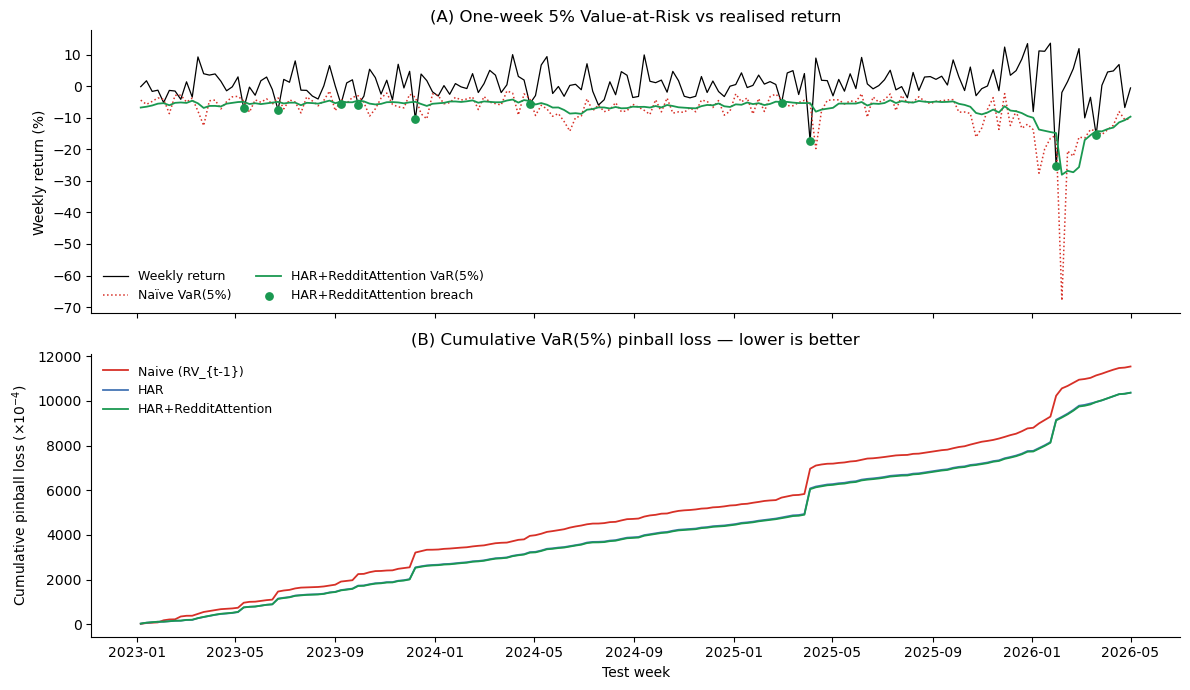

In [6]:
# Figure: VaR bands + cumulative pinball loss
alpha = 0.05; za = z_alpha(alpha, 'normal')
VARS = {k: mu + s * za for k, s in SIG.items()}
PL   = {k: pinball_series(r, VARS[k], alpha) for k in SIG}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(idx, r * 100, color='black', lw=0.9, label='Weekly return')
ax1.plot(idx, VARS['Naive (RV_{t-1})'] * 100, color='#d73027', lw=1.1, ls=':', label='Naïve VaR(5%)')
ax1.plot(idx, VARS['HAR+RedditAttention'] * 100, color='#1a9850', lw=1.3, label='HAR+RedditAttention VaR(5%)')
br = r < VARS['HAR+RedditAttention']
ax1.scatter(idx[br], r[br] * 100, color='#1a9850', s=28, zorder=5, label='HAR+RedditAttention breach')
ax1.set_ylabel('Weekly return (%)'); ax1.legend(frameon=False, ncol=2, fontsize=9)
ax1.set_title('(A) One-week 5% Value-at-Risk vs realised return')
for sp in ('top', 'right'): ax1.spines[sp].set_visible(False)

for k, c in [('Naive (RV_{t-1})', '#d73027'), ('HAR', '#4575b4'), ('HAR+RedditAttention', '#1a9850')]:
    ax2.plot(idx, np.cumsum(PL[k]) * 1e4, color=c, lw=1.3, label=k)
ax2.set_ylabel(r'Cumulative pinball loss ($\times10^{-4}$)')
ax2.set_xlabel('Test week'); ax2.legend(frameon=False, fontsize=9)
ax2.set_title('(B) Cumulative VaR(5%) pinball loss — lower is better')
for sp in ('top', 'right'): ax2.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig('../../images/var_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

**What the pinball loss in panel (B) measures.** The curve is the running sum of the
per-week *pinball loss* — the proper scoring rule for the VaR cutoff, which is an
$\alpha$-quantile forecast of next week's return:

$$L_\alpha(r_t, V_t) = \begin{cases} \alpha\,(r_t - V_t), & r_t \geq V_t \quad\text{(no breach)} \\ (1-\alpha)\,(V_t - r_t), & r_t < V_t \quad\text{(breach)} \end{cases}$$

The key is the **asymmetric penalty**. For a 5% VaR ($\alpha=0.05$):

- **No breach** (return above the cutoff) → penalty $0.05\times$ distance. Small weight —
  gently punishes a VaR that is *too conservative* (cutoff parked too far out, wasting capital).
- **Breach** (return below the cutoff) → penalty $0.95\times$ distance. Big weight —
  heavily punishes a VaR that was *too optimistic* and got blown through.

The 19:1 split is what pins the loss-minimising cutoff at the true 5th percentile. On the
chart the **slope** is each week's loss and the **height** the accumulated total, so a line
that stays lower is the better-calibrated VaR.

## Takeaway

The backtest establishes **risk-management relevance** for forecastable volatility: at Normal
5% VaR, HAR significantly improves pinball loss relative to carrying forward last week's realised
volatility ($p<0.001$). The naïve forecast also fails badly in the Normal 1% tail. GARCH is highly
competitive in VaR calibration even though it ranks below HAR on the chapter's original RV point-
forecast metrics; coverage and point-forecast accuracy answer different questions.

The extra benefit from sentiment is much weaker. Reddit attention changes the Normal 1% result by
one breach and improves pinball loss only at the 10% level; switching to Student-$t_5$ innovations
already makes bare HAR pass coverage. The defensible conclusion is therefore: **HAR improves on
naïve VaR; GARCH is competitive; sentiment offers suggestive, tail-specific refinement rather than
a robust new winner.**

Outputs: `metrics_var_backtest_volatility.csv`, `images/var_backtest.png`.